# Day 3: CHB-MIT seizure detection from raw EEG
Runtime > Change runtime type > **T4 GPU**, then run the cells in order. Expect roughly 1.5-3 hours in total; the window cache is written per case, so a disconnect can be resumed by re-running the same cell.

In [2]:
import torch; print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU')

Tesla T4


In [3]:
!pip -q install mne awscli joblib
!git clone -q https://github.com/aryan9-6-5/MedTech-Suite.git
%cd MedTech-Suite/day-3-chbmit-seizure-detection
!mkdir -p data results

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 115.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 97.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 45.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
/content/MedTech-Suite/day-3-chbmit-seizure-detection


In [4]:
# CHB-MIT from PhysioNet's public S3 mirror: EDF files + per-case summaries (~42 GB)
!df -h /content | tail -1
!aws s3 sync --no-sign-request --only-show-errors s3://physionet-open/chbmit/1.0.0 data/chbmit --exclude "*" --include "*.edf" --include "*-summary.txt" --include "RECORDS"
!df -h /content | tail -1

overlay         113G   43G   71G  38% /
overlay         113G   86G   28G  76% /


In [5]:
# sanity check: every file in RECORDS should be on disk
from pathlib import Path
rec=[l.strip() for l in open('data/chbmit/RECORDS') if l.strip()]
missing=[r for r in rec if not Path('data/chbmit',r).exists()]
print(len(rec),'records listed;',len(missing),'missing', missing[:5])

686 records listed; 0 missing []


In [6]:
%cd src
# 18-channel bipolar montage, 0.5-45 Hz, 4 s windows. Cached per case (resumable).
!python cache.py

/content/MedTech-Suite/day-3-chbmit-seizure-detection/src
chb01 chb01_01.edf pos 0 bg 60
chb01 chb01_02.edf pos 0 bg 60
chb01 chb01_03.edf pos 40 bg 58
chb01 chb01_04.edf pos 27 bg 58
chb01 chb01_05.edf pos 0 bg 60
chb01 chb01_06.edf pos 0 bg 60
chb01 chb01_07.edf pos 0 bg 60
chb01 chb01_08.edf pos 0 bg 60
chb01 chb01_09.edf pos 0 bg 60
chb01 chb01_10.edf pos 0 bg 60
chb01 chb01_11.edf pos 0 bg 60
chb01 chb01_12.edf pos 0 bg 60
chb01 chb01_13.edf pos 0 bg 60
chb01 chb01_14.edf pos 0 bg 60
chb01 chb01_15.edf pos 40 bg 57
chb01 chb01_16.edf pos 51 bg 57
chb01 chb01_17.edf pos 0 bg 60
chb01 chb01_18.edf pos 90 bg 56
chb01 chb01_19.edf pos 0 bg 60
chb01 chb01_20.edf pos 0 bg 44
chb01 chb01_21.edf pos 93 bg 56
chb01 chb01_22.edf pos 0 bg 60
chb01 chb01_23.edf pos 0 bg 60
chb01 chb01_24.edf pos 0 bg 60
chb01 chb01_25.edf pos 0 bg 60
chb01 chb01_26.edf pos 101 bg 35
chb01 chb01_27.edf pos 0 bg 10
chb01 chb01_29.edf pos 0 bg 60
chb01 chb01_30.edf pos 0 bg 60
chb01 chb01_31.edf pos 0 bg 60
chb0

In [7]:
# 1D CNN on raw windows, patient-level split (held-out patients never seen in training)
!python train.py

mode=patient train=49654 (pos 7595) val=6526 test=12595
epoch 01 val AUPRC 0.7651 AUROC 0.8758
epoch 02 val AUPRC 0.7571 AUROC 0.8844
epoch 03 val AUPRC 0.7170 AUROC 0.8569
epoch 04 val AUPRC 0.6542 AUROC 0.8201
epoch 05 val AUPRC 0.7376 AUROC 0.8688
epoch 06 val AUPRC 0.7201 AUROC 0.8577
epoch 07 val AUPRC 0.7494 AUROC 0.8633
epoch 08 val AUPRC 0.7558 AUROC 0.8750
epoch 09 val AUPRC 0.7339 AUROC 0.8577
epoch 10 val AUPRC 0.7787 AUROC 0.8835
epoch 11 val AUPRC 0.7501 AUROC 0.8735
epoch 12 val AUPRC 0.7427 AUROC 0.8610
epoch 13 val AUPRC 0.7796 AUROC 0.8838
epoch 14 val AUPRC 0.7743 AUROC 0.8794
epoch 15 val AUPRC 0.7744 AUROC 0.8795
{
  "mode": "patient",
  "model": "cnn",
  "val_best_auprc": 0.7795752324159144,
  "best_epoch": 13,
  "test": {
    "auroc": 0.7539775625444075,
    "auprc": 0.4012190441102396,
    "prevalence": 0.14847161572052403,
    "n": 12595,
    "n_pos": 1870
  }
}


In [8]:
!python baseline.py

{
  "mode": "patient",
  "model": "baseline",
  "val": {
    "auroc": 0.950721009809893,
    "auprc": 0.8920446465408651,
    "prevalence": 0.25436714679742567,
    "n": 6526,
    "n_pos": 1660
  },
  "test": {
    "auroc": 0.8504488737643817,
    "auprc": 0.6730521529499024,
    "prevalence": 0.14847161572052403,
    "n": 12595,
    "n_pos": 1870
  }
}


In [9]:
# score every validation and test recording end to end (no sampling)
!python score.py

chb08 chb08_02.edf 3597 windows, 1 seizures
chb08 chb08_03.edf 3597 windows, 0 seizures
chb08 chb08_04.edf 3597 windows, 0 seizures
chb08 chb08_05.edf 3597 windows, 1 seizures
chb08 chb08_10.edf 3597 windows, 0 seizures
chb08 chb08_11.edf 3597 windows, 1 seizures
chb08 chb08_12.edf 3597 windows, 0 seizures
chb08 chb08_13.edf 3597 windows, 1 seizures
chb08 chb08_14.edf 3597 windows, 0 seizures
chb08 chb08_15.edf 3597 windows, 0 seizures
chb08 chb08_16.edf 3597 windows, 0 seizures
chb08 chb08_17.edf 3597 windows, 0 seizures
chb08 chb08_18.edf 3597 windows, 0 seizures
chb08 chb08_19.edf 3597 windows, 0 seizures
chb08 chb08_20.edf 3597 windows, 0 seizures
chb08 chb08_21.edf 3597 windows, 1 seizures
chb08 chb08_22.edf 3597 windows, 0 seizures
chb08 chb08_23.edf 3597 windows, 0 seizures
chb08 chb08_24.edf 3597 windows, 0 seizures
chb08 chb08_29.edf 3620 windows, 0 seizures
chb18 chb18_01.edf 3608 windows, 0 seizures
chb18 chb18_02.edf 3597 windows, 0 seizures
chb18 chb18_03.edf 3597 windows,

In [10]:
!python evaluate.py

val files 65, test files 157
CNN {
 "detected": 16,
 "seizures": 35,
 "sensitivity": 0.45714285714285713,
 "false_alarms": 858,
 "hours": 179.81833333333338,
 "fa_per_hour": 4.771482329387992,
 "median_latency_s": 24.5
}
Baseline {
 "detected": 13,
 "seizures": 35,
 "sensitivity": 0.37142857142857144,
 "false_alarms": 707,
 "hours": 179.81833333333338,
 "fa_per_hour": 3.931745928761434,
 "median_latency_s": 14.0
}


### Leakage comparison
Same CNN and baseline, but windows split at random across all patients (neighbouring windows from one recording land on both sides).

In [11]:
!SPLIT=random python train.py
!SPLIT=random python baseline.py

mode=random train=48142 (pos 7849) val=10316 test=10317
epoch 01 val AUPRC 0.8554 AUROC 0.9483
epoch 02 val AUPRC 0.8992 AUROC 0.9666
epoch 03 val AUPRC 0.9291 AUROC 0.9764
epoch 04 val AUPRC 0.9436 AUROC 0.9825
epoch 05 val AUPRC 0.9606 AUROC 0.9885
epoch 06 val AUPRC 0.9622 AUROC 0.9890
epoch 07 val AUPRC 0.9526 AUROC 0.9866
epoch 08 val AUPRC 0.9587 AUROC 0.9894
epoch 09 val AUPRC 0.9831 AUROC 0.9955
epoch 10 val AUPRC 0.9850 AUROC 0.9961
epoch 11 val AUPRC 0.9887 AUROC 0.9971
epoch 12 val AUPRC 0.9904 AUROC 0.9976
epoch 13 val AUPRC 0.9916 AUROC 0.9980
epoch 14 val AUPRC 0.9913 AUROC 0.9978
epoch 15 val AUPRC 0.9915 AUROC 0.9979
{
  "mode": "random",
  "model": "cnn",
  "val_best_auprc": 0.9915543522854883,
  "best_epoch": 13,
  "test": {
    "auroc": 0.9971665788814442,
    "auprc": 0.9874706948552229,
    "prevalence": 0.1624503247067946,
    "n": 10317,
    "n_pos": 1676
  }
}
{
  "mode": "random",
  "model": "baseline",
  "val": {
    "auroc": 0.9948093305415328,
    "auprc": 0

/content/MedTech-Suite/day-3-chbmit-seizure-detection
results/windows_baseline_patient.json {
 "mode": "patient",
 "model": "baseline",
 "val": {
  "auroc": 0.950721009809893,
  "auprc": 0.8920446465408651,
  "prevalence": 0.25436714679742567,
  "n": 6526,
  "n_pos": 1660
 },
 "test": {
  "auroc": 0.8504488737643817,
  "auprc": 0.6730521529499024,
  "prevalence": 0.14847161572052403,
  "n": 12595,
  "n_pos": 1870
 }
}
results/windows_baseline_random.json {
 "mode": "random",
 "model": "baseline",
 "val": {
  "auroc": 0.9948093305415328,
  "auprc": 0.9801722732327103,
  "prevalence": 0.15509887553315238,
  "n": 10316,
  "n_pos": 1600
 },
 "test": {
  "auroc": 0.9945773866555598,
  "auprc": 0.981796898150413,
  "prevalence": 0.1624503247067946,
  "n": 10317,
  "n_pos": 1676
 }
}
results/windows_cnn_patient.json {
 "mode": "patient",
 "model": "cnn",
 "val_best_auprc": 0.7795752324159144,
 "best_epoch": 13,
 "test": {
  "auroc": 0.7539775625444075,
  "auprc": 0.4012190441102396,
  "preval

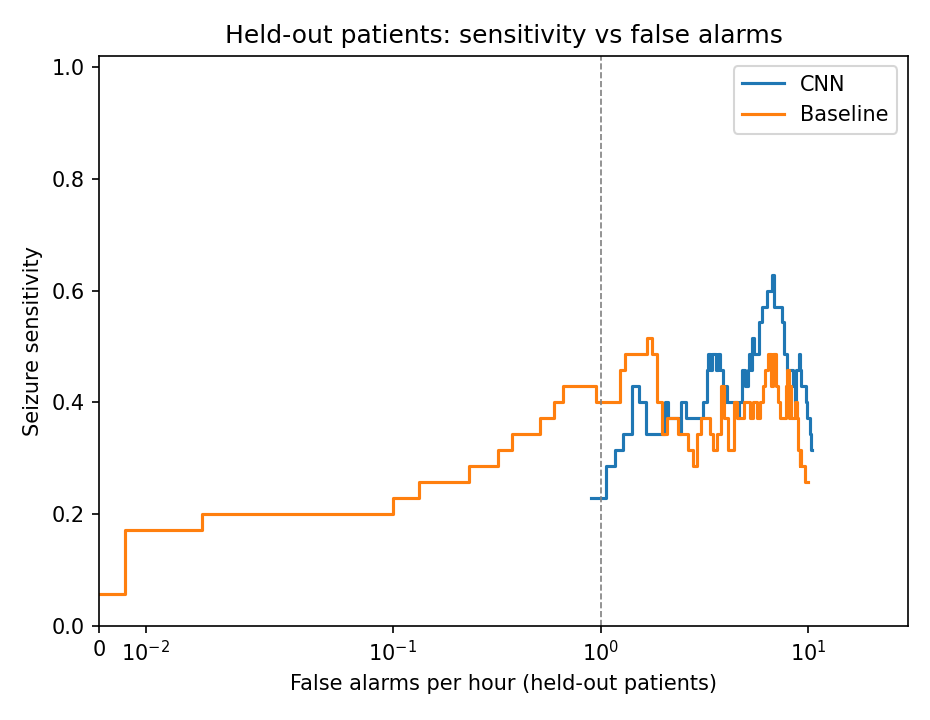

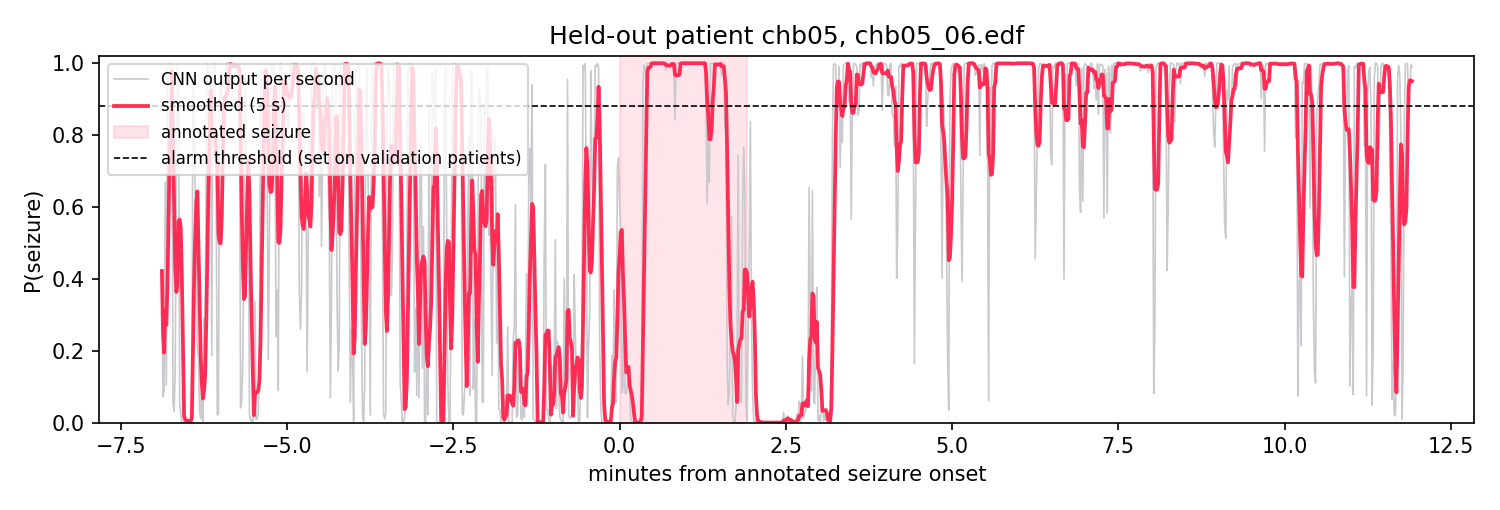

In [12]:
%cd ..
import json, glob
from IPython.display import Image, display
for f in sorted(glob.glob('results/windows_*.json')):
    m=json.load(open(f)); m.pop('history',None); print(f, json.dumps(m, indent=1))
print(open('results/events.json').read())
for f in ('sens_vs_fa','timeline'): display(Image(f'results/{f}.png'))